# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [2]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [3]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [4]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [5]:
import random

SEED = 42

def set_seed():
    random.seed(SEED)

numbers = list(range(10))
print("ДО set_seed():")
print("randint:", random.randint(1, 100))
numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)
print("randint:", random.randint(1, 100))
numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)
set_seed()
print("\nSeed зафіксовано:", SEED)

print("\nПІСЛЯ set_seed() з повторним set_seed():")
set_seed()
print("randint:", random.randint(1, 100))
set_seed()
print("randint:", random.randint(1, 100))
set_seed()
numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)
set_seed()
numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)

print("\nПІСЛЯ set_seed() без проміжного set_seed():")
set_seed()
print("randint:", random.randint(1, 100))
print("randint:", random.randint(1, 100))
numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)
random.shuffle(numbers)
print("shuffle:", numbers)

ДО set_seed():
randint: 24
shuffle: [7, 6, 3, 8, 4, 5, 2, 9, 1, 0]
randint: 55
shuffle: [9, 1, 3, 5, 8, 2, 4, 0, 6, 7]

Seed зафіксовано: 42

ПІСЛЯ set_seed() з повторним set_seed():
randint: 82
randint: 82
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]

ПІСЛЯ set_seed() без проміжного set_seed():
randint: 82
randint: 15
shuffle: [7, 5, 2, 8, 9, 6, 1, 3, 4, 0]
shuffle: [6, 8, 2, 4, 9, 1, 3, 5, 0, 7]


set_seed() задає генератору псевдовипадкових чисел певний початковий стан. Якщо перед кожною генерацією числового ряду встановлювати однаковий seed то отримана послідовність псевдовипадкових чисел буде однакова.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [6]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [7]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [8]:
import numpy as np

zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print("Масив з нулями:")
print(zeros_arr)
print("shape:", zeros_arr.shape)
print("dtype:", zeros_arr.dtype)

print("\nМасив із сімками:")
print(sevens_arr)
print("shape:", sevens_arr.shape)
print("dtype:", sevens_arr.dtype)

Масив з нулями:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
shape: (3, 4)
dtype: float64

Масив із сімками:
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]]
shape: (3, 4)
dtype: int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [9]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)

[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [10]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)

print(identity.ndim)
print(random_ints.ndim)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[2 0 5]
 [4 7 9]
 [6 8 0]]
2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [11]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)

Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [13]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [14]:
df = pd.DataFrame({
    "name": ["Ярик", "Саша", "Віталік", "Богдан", "Паша"],
    "score": [85, 72, 94, 81, 68]
})

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням

top = df[df["score"] > 80].sort_values("score", ascending=False)
print(top)

      name  score
2  Віталік     94
0     Ярик     85
3   Богдан     81


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [16]:
df = pd.DataFrame({
    "name": ["Ярик", "Саша", "Віталік", "Богдан", "Паша"],
    "score": [94,97,95,78,67]
})

df["grade"] = "C"

df.loc[df["score"] >= 75, "grade"] = "B"
df.loc[df["score"] >= 90, "grade"] = "A"

print(df)

      name  score grade
0     Ярик     94     A
1     Саша     97     A
2  Віталік     95     A
3   Богдан     78     B
4     Паша     67     C


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [17]:
import torch

zeros_tensor = torch.zeros(2, 3)

full_tensor = torch.full((2, 3), 7)

print("zeros_tensor:")
print(zeros_tensor)
print("shape:", zeros_tensor.shape)
print("dtype:", zeros_tensor.dtype)

print("\nfull_tensor:")
print(full_tensor)
print("shape:", full_tensor.shape)
print("dtype:", full_tensor.dtype)

zeros_tensor:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32

full_tensor:
tensor([[7, 7, 7],
        [7, 7, 7]])
shape: torch.Size([2, 3])
dtype: torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [18]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)

tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [19]:

from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print("shape:", from_list.shape, "dtype:", from_list.dtype, "ndim:", from_list.ndim)

print(random_t)
print("shape:", random_t.shape, "dtype:", random_t.dtype, "ndim:", random_t.ndim)

tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2]) dtype: torch.int64 ndim: 2
tensor([[0.4408, 0.4294, 0.0022],
        [0.3958, 0.3640, 0.1100],
        [0.3632, 0.0271, 0.3446]])
shape: torch.Size([3, 3]) dtype: torch.float32 ndim: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [20]:
n = 5.0

# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

# надрукувати x.grad.item() і порівняти з 2 * n
print(x.grad.item())
print(2*n)



10.0
10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [22]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
for i in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()

    with torch.no_grad():
        x -= lr * x.grad

    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

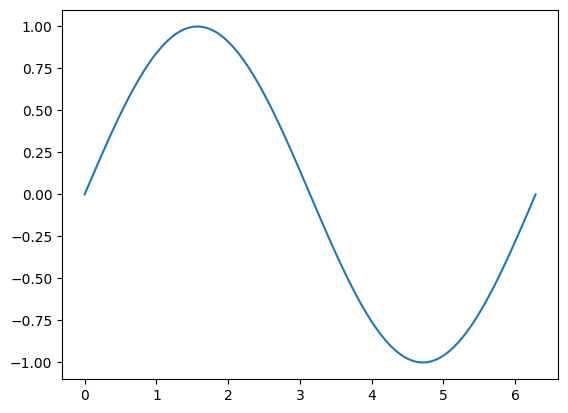

In [23]:
# TODO: xs = np.linspace(0, 2*np.pi, 100), plt.plot(xs, np.sin(xs)), plt.show()
xs = np.linspace(0, 2 * np.pi, 100)

plt.plot(xs, np.sin(xs))
plt.show()

**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

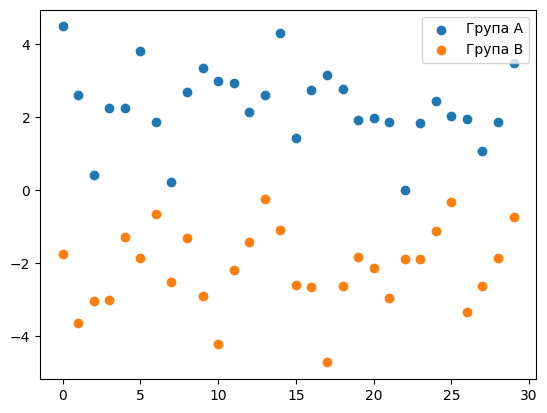

In [24]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()

x = np.arange(30)

plt.scatter(x, group_a, color="C0", label="Група A")
plt.scatter(x, group_b, color="C1", label="Група B")

plt.legend()
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [25]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

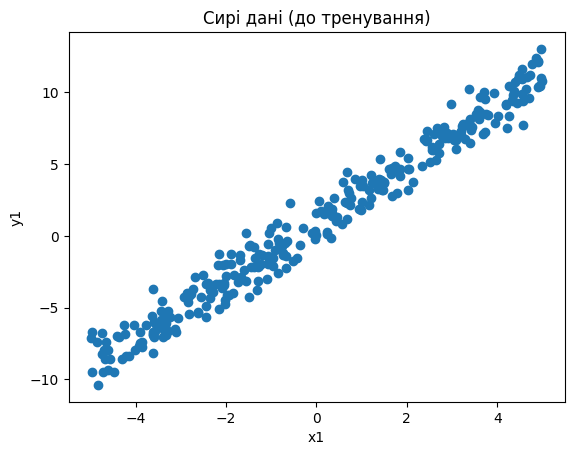

In [26]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"
plt.scatter(x1.squeeze().numpy(), y1.squeeze().numpy())

plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")

plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [27]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...

indices = torch.randperm(TASK1_N)

x1_shuffled = x1[indices]
y1_shuffled = y1[indices]

n_train = int(0.70 * TASK1_N)
n_val = int(0.15 * TASK1_N)

x_train1 = x1_shuffled[:n_train]
y_train1 = y1_shuffled[:n_train]

x_val1 = x1_shuffled[n_train:n_train + n_val]
y_val1 = y1_shuffled[n_train:n_train + n_val]

x_test1 = x1_shuffled[n_train + n_val:]
y_test1 = y1_shuffled[n_train + n_val:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [28]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=46.824715  w=1.6756 (true 2.0)  b=-0.6628 (true 1.0)
epoch   30  loss=0.860496  w=2.0323 (true 2.0)  b=0.8605 (true 1.0)
epoch   60  loss=0.854747  w=2.0303 (true 2.0)  b=0.9261 (true 1.0)
epoch   90  loss=0.854736  w=2.0302 (true 2.0)  b=0.9289 (true 1.0)
epoch   99  loss=0.854736  w=2.0302 (true 2.0)  b=0.9290 (true 1.0)


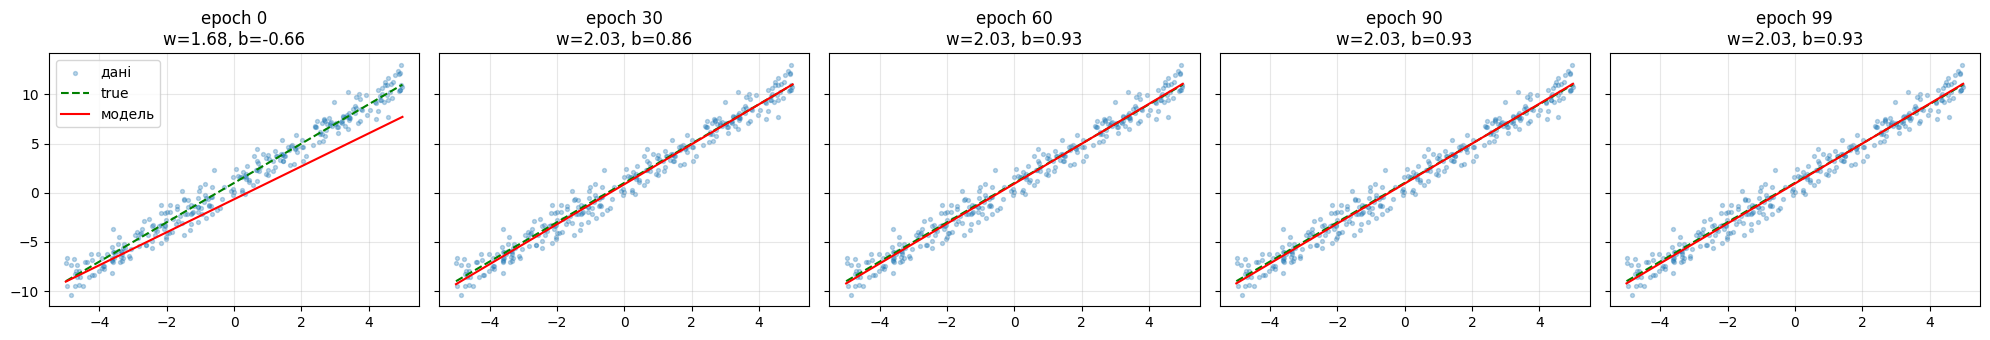

In [29]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

Моя тема: "Нарахування заробітної плати працівника поштового терміналу". Суть задачі полягає в тому, що денний заробіток працівника сортувального центру залежить від кількості оброблених посилок за зміну.

Позначимо через x кількість десятків оброблених посилок. Наприклад, x = 5 означає 50 оброблених посилок. Значення y це денний заробіток працівника у гривнях.


In [30]:
TASK20_TRUE_W = 80.0
TASK20_TRUE_B = 450.0
TASK20_N = 300
TASK20_NOISE_STD = 40.0


def generate_post_dataset(
    n=TASK20_N,
    w=TASK20_TRUE_W,
    b=TASK20_TRUE_B,
    noise_std=TASK20_NOISE_STD,
    seed=42
):
    torch.manual_seed(seed)
    parcels_count = torch.randint(20, 101, (n, 1)).float()

    # x вимірюємо десятками посилок:
    x_tens = parcels_count / 10.0

    # Випадковий шум
    noise = noise_std * torch.randn(n, 1)

    # y = wx + b + noise
    income = w * x_tens + b + noise

    df = pd.DataFrame({
        "parcels_count": parcels_count.squeeze().numpy().astype(int),
        "x_tens": x_tens.squeeze().numpy(),
        "daily_income_uah": income.squeeze().numpy()
    })

    return df


task20_df = generate_post_dataset()

print(task20_df.head())
print("\nКількість записів:", len(task20_df))

   parcels_count  x_tens  daily_income_uah
0             80     8.0       1067.712524
1             43     4.3        755.266113
2             27     2.7        700.851196
3             96     9.6       1214.174316
4             29     2.9        698.152100

Кількість записів: 300


In [31]:
task20_df.to_csv("dataset.csv", index=False)

print("Дані збережено у dataset.csv")

Дані збережено у dataset.csv


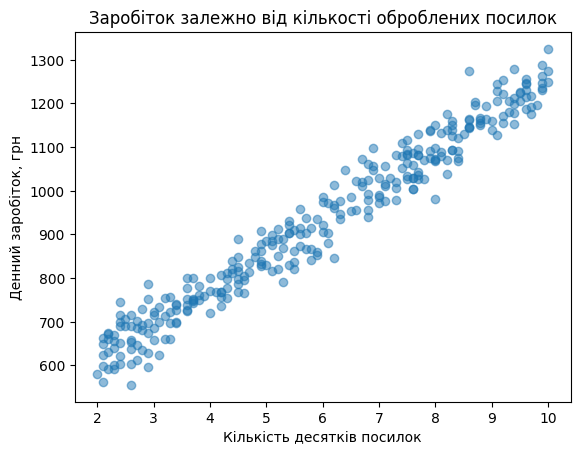

In [32]:
# Перевірка з графіком

plt.scatter(
    task20_df["x_tens"],
    task20_df["daily_income_uah"],
    alpha=0.5
)

plt.xlabel("Кількість десятків посилок")
plt.ylabel("Денний заробіток, грн")
plt.title("Заробіток залежно від кількості оброблених посилок")

plt.show()

In [39]:
def split_data(x, y, train_ratio=0.70, val_ratio=0.15, seed=42):
    generator = torch.Generator().manual_seed(seed)

    indices = torch.randperm(len(x), generator=generator)

    x_shuffled = x[indices]
    y_shuffled = y[indices]

    n_train = int(train_ratio * len(x))
    n_val = int(val_ratio * len(x))

    x_train = x_shuffled[:n_train]
    y_train = y_shuffled[:n_train]

    x_val = x_shuffled[n_train:n_train + n_val]
    y_val = y_shuffled[n_train:n_train + n_val]

    x_test = x_shuffled[n_train + n_val:]
    y_test = y_shuffled[n_train + n_val:]

    return x_train, y_train, x_val, y_val, x_test, y_test


x20 = torch.tensor(
    task20_df["x_tens"].values,
    dtype=torch.float32
).unsqueeze(1)

y20 = torch.tensor(
    task20_df["daily_income_uah"].values,
    dtype=torch.float32
).unsqueeze(1)

print("x shape:", x20.shape)
print("y shape:", y20.shape)

(
  x_train20,
  y_train20,
  x_val20,
  y_val20,
  x_test20,
  y_test20
) = split_data(x20, y20)

print(
    f"train/val/test: "
    f"{len(x_train20)}/{len(x_val20)}/{len(x_test20)}"
)

x shape: torch.Size([300, 1])
y shape: torch.Size([300, 1])
train/val/test: 210/45/45


In [41]:
# Функція навчання

def train_linear_model(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=1500,
    lr=0.02,
    seed=42
):
    torch.manual_seed(seed)

    model = torch.nn.Linear(
        in_features=1,
        out_features=1
    )

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
    )

    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        # 1. Очищення старих градієнтів
        optimizer.zero_grad()

        # 2. Прогноз на train
        y_pred = model(x_train)

        # 3. Обчислення помилки
        train_loss = loss_fn(y_pred, y_train)

        # 4. Обчислення градієнтів
        train_loss.backward()

        # 5. Оновлення w і b
        optimizer.step()

        # Періодично дивимося на validation
        if epoch % 300 == 0 or epoch == epochs - 1:
            with torch.no_grad():
                val_pred = model(x_val)
                val_loss = loss_fn(val_pred, y_val)

            print(
                f"epoch {epoch:4d} | "
                f"train MSE = {train_loss.item():.2f} | "
                f"val MSE = {val_loss.item():.2f}"
            )

    return model

In [48]:
task20_model = train_linear_model(
    x_train20,
    y_train20,
    x_val20,
    y_val20
)

epoch    0 | train MSE = 878733.62 | val MSE = 449518.84
epoch  300 | train MSE = 2563.15 | val MSE = 2332.13
epoch  600 | train MSE = 1593.82 | val MSE = 1213.01
epoch  900 | train MSE = 1554.95 | val MSE = 1161.65
epoch 1200 | train MSE = 1553.39 | val MSE = 1158.29
epoch 1499 | train MSE = 1553.33 | val MSE = 1157.90


In [50]:
learned_w = task20_model.weight.item()
learned_b = task20_model.bias.item()

print(f"Навчений w: {learned_w:.2f}")
print(f"Справжній w: {TASK20_TRUE_W:.2f}")

print(f"Навчений b: {learned_b:.2f}")
print(f"Справжній b: {TASK20_TRUE_B:.2f}")

Навчений w: 81.13
Справжній w: 80.00
Навчений b: 451.53
Справжній b: 450.00


In [53]:
# Перевірка на тест
def evaluate_model(model, x_test, y_test):
    loss_fn = torch.nn.MSELoss()

    with torch.no_grad():
        y_pred = model(x_test)
        test_loss = loss_fn(y_pred, y_test)

    return test_loss.item()

test_mse20 = evaluate_model(
  task20_model,
  x_test20,
  y_test20
)
print(f"Test MSE: {test_mse20:.2f}")

Test MSE: 1859.61


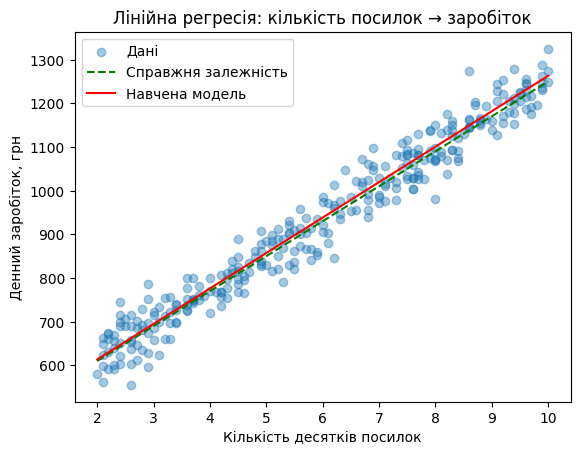

In [54]:
# Графік

with torch.no_grad():
    x_line20 = torch.linspace(2, 10, 100).unsqueeze(1)

    # Справжня залежність
    y_true20 = (
        TASK20_TRUE_W * x_line20
        + TASK20_TRUE_B
    )

    # Лінія, яку вивчила модель
    y_pred20 = task20_model(x_line20)


plt.scatter(
    x20.numpy(),
    y20.numpy(),
    alpha=0.4,
    label="Дані"
)

plt.plot(
    x_line20.numpy(),
    y_true20.numpy(),
    "g--",
    label="Справжня залежність"
)

plt.plot(
    x_line20.numpy(),
    y_pred20.numpy(),
    "r-",
    label="Навчена модель"
)

plt.xlabel("Кількість десятків посилок")
plt.ylabel("Денний заробіток, грн")
plt.title("Лінійна регресія: кількість посилок → заробіток")

plt.legend()
plt.show()

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [55]:
MODEL_PATH = "/content/drive/MyDrive/ai_systems/lab1/model.pt"

torch.save(
    task20_model.state_dict(),
    MODEL_PATH
)

print("Модель збережено:", MODEL_PATH)

Модель збережено: /content/drive/MyDrive/ai_systems/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [56]:
!pip install -q gradio
import gradio as gr

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/ai_systems/lab1/model.pt"

gradio_model = torch.nn.Linear(1, 1)

gradio_model.load_state_dict(
    torch.load(MODEL_PATH, map_location="cpu")
)

gradio_model.eval()

def predict_income(parcels_count):
    if parcels_count is None:
        return None

    if parcels_count < 0:
        raise gr.Error("Кількість посилок не може бути від’ємною")

    if parcels_count == 0:
        raise gr.Error("Кількість посилок має бути більшою за 0")

    x_value = float(parcels_count) / 10.0

    x_tensor = torch.tensor(
        [[x_value]],
        dtype=torch.float32
    )

    with torch.no_grad():
        prediction = gradio_model(x_tensor).item()

    return round(prediction, 2)

In [60]:
demo = gr.Interface(
    fn=predict_income,

    inputs=gr.Number(
        label="Кількість оброблених посилок за зміну",
        precision=0,
        placeholder="Наприклад: 50"
    ),

    outputs=gr.Number(
        label="Прогнозований денний заробіток, грн"
    ),

    title="Прогноз денного заробітку працівника сортувального центру",

    description=(
        "Введіть кількість оброблених посилок за зміну "
        "Модель лінійної регресії спрогнозує денний заробіток працівника"
    )
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://687a84afe4478b66ad.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```